# GRA: lion — Rel vs GR

project = ```GRA```, host = ```mach```, device = ```cuda:1```

## Goals:

Test these Lion extensions:

**relativistic**
vs.
**general relativistic**

on `CIFAR10`

In [1]:
# HIDE CODE


project_name = '_GRA'


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, project_name))
from utils.plotting import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: mach

## Main

In [3]:
from optimzers import *
from test.test import *

In [4]:
cfg = TrainConfig(
    dataset='CIFAR10',
    # dataset='ImageNet32',
    batch_size=256,
    epochs=20,
    device=device,
    data_on_device=True,
    verbose=True,
    amp=False,
)

In [5]:
experiments_gr_lion = [
    Experiment(
        f"GR. Lion — lr={lr},mass={m},gamma={g},b3={b3}",
        make_opt(GeneralRelativisticLion, lr=lr, mass=m, gamma=g, beta_gravity=b3, betas=(0.8, 0.99)),
    ) for lr, m, g, b3 in itertools.product([1e-3], [1, 10, 100, 1000], [1.0, 0.01, 100], [0.99, 0.9, 0.5])
]

experiments_rel_lion = [
    Experiment(
        f"Rel. Lion — lr={lr},mass={m}",
        make_opt(RelativisticLion, lr=lr, mass=m, betas=(0.8, 0.99), use_curvature=False),
    ) for lr, m in itertools.product([1e-3], [100])
]

experiments = experiments_gr_lion + experiments_rel_lion
len(experiments)

37

In [6]:
print(experiments)

[
    Experiment(
        name='GR. Lion — lr=0.001,mass=1,gamma=1.0,b3=0.99',
        opt_fn=<function make_opt.<locals>._fn at 0x7dfea2124d60>
    ),
    Experiment(
        name='GR. Lion — lr=0.001,mass=1,gamma=1.0,b3=0.9',
        opt_fn=<function make_opt.<locals>._fn at 0x7dfea2125120>
    ),
    Experiment(
        name='GR. Lion — lr=0.001,mass=1,gamma=1.0,b3=0.5',
        opt_fn=<function make_opt.<locals>._fn at 0x7dfea2124e00>
    ),
    Experiment(
        name='GR. Lion — lr=0.001,mass=1,gamma=0.01,b3=0.99',
        opt_fn=<function make_opt.<locals>._fn at 0x7dfea21251c0>
    ),
    Experiment(
        name='GR. Lion — lr=0.001,mass=1,gamma=0.01,b3=0.9',
        opt_fn=<function make_opt.<locals>._fn at 0x7dfea2125260>
    ),
    Experiment(
        name='GR. Lion — lr=0.001,mass=1,gamma=0.01,b3=0.5',
        opt_fn=<function make_opt.<locals>._fn at 0x7dfea2125300>
    ),
    Experiment(
        name='GR. Lion — lr=0.001,mass=1,gamma=100,b3=0.99',
        opt_fn=<function make_opt.<locals>._fn at 0x7dfea21253a0>
    ),
    Experiment(
        name='GR. Lion — lr=0.001,mass=1,gamma=100,b3=0.9',
        opt_fn=<function make_opt.<locals>._fn at 0x7dfea21254e0>
    ),
    Experiment(
        name='GR. Lion — lr=0.001,mass=1,gamma=100,b3=0.5',
        opt_fn=<function make_opt.<locals>._fn at 0x7dfea2125620>
    ),
    Experiment(
        name='GR. Lion — lr=0.001,mass=10,gamma=1.0,b3=0.99',
        opt_fn=<function make_opt.<locals>._fn at 0x7dfea21256c0>
    ),
    Experiment(
        name='GR. Lion — lr=0.001,mass=10,gamma=1.0,b3=0.9',
        opt_fn=<function make_opt.<locals>._fn at 0x7dfea2125760>
    ),
    Experiment(
        name='GR. Lion — lr=0.001,mass=10,gamma=1.0,b3=0.5',
        opt_fn=<function make_opt.<locals>._fn at 0x7dfea2125800>
    ),
    Experiment(
        name='GR. Lion — lr=0.001,mass=10,gamma=0.01,b3=0.99',
        opt_fn=<function make_opt.<locals>._fn at 0x7dfea21258a0>
    ),
    Experiment(
        name='GR. Lion — lr=0.001,mass=10,gamma=0.01,b3=0.9',
        opt_fn=<function make_opt.<locals>._fn at 0x7dfea21259e0>
    ),
    Experiment(
        name='GR. Lion — lr=0.001,mass=10,gamma=0.01,b3=0.5',
        opt_fn=<function make_opt.<locals>._fn at 0x7dfea2125b20>
    ),
    Experiment(
        name='GR. Lion — lr=0.001,mass=10,gamma=100,b3=0.99',
        opt_fn=<function make_opt.<locals>._fn at 0x7dfea2125bc0>
    ),
    Experiment(
        name='GR. Lion — lr=0.001,mass=10,gamma=100,b3=0.9',
        opt_fn=<function make_opt.<locals>._fn at 0x7dfea2125c60>
    ),
    Experiment(
        name='GR. Lion — lr=0.001,mass=10,gamma=100,b3=0.5',
        opt_fn=<function make_opt.<locals>._fn at 0x7dfea2125d00>
    ),
    Experiment(
        name='GR. Lion — lr=0.001,mass=100,gamma=1.0,b3=0.99',
        opt_fn=<function make_opt.<locals>._fn at 0x7dfea2125da0>
    ),
    Experiment(
        name='GR. Lion — lr=0.001,mass=100,gamma=1.0,b3=0.9',
        opt_fn=<function make_opt.<locals>._fn at 0x7dfea2125e40>
    ),
    Experiment(
        name='GR. Lion — lr=0.001,mass=100,gamma=1.0,b3=0.5',
        opt_fn=<function make_opt.<locals>._fn at 0x7dfea2125ee0>
    ),
    Experiment(
        name='GR. Lion — lr=0.001,mass=100,gamma=0.01,b3=0.99',
        opt_fn=<function make_opt.<locals>._fn at 0x7dfea2125f80>
    ),
    Experiment(
        name='GR. Lion — lr=0.001,mass=100,gamma=0.01,b3=0.9',
        opt_fn=<function make_opt.<locals>._fn at 0x7dfea2126020>
    ),
    Experiment(
        name='GR. Lion — lr=0.001,mass=100,gamma=0.01,b3=0.5',
        opt_fn=<function make_opt.<locals>._fn at 0x7dfea21260c0>
    ),
    Experiment(
        name='GR. Lion — lr=0.001,mass=100,gamma=100,b3=0.99',
        opt_fn=<function make_opt.<locals>._fn at 0x7dfea2126160>
    ),
    Experiment(
        name='GR. Lion — lr=0.001,mass=100,gamma=100,b3=0.9',
        opt_fn=<function make_opt.<locals>._fn at 0x7dfea2126200>
    ),
    Experiment(
        name='GR. Lion — lr=0.001,mass=100,gamma=100,b3=0.5',
   

In [7]:
results = run_experiments(experiments, cfg=cfg, seeds=[0])

--- Training (CIFAR10) ---

Model: ConvNet | seed=0
Optimizer: GeneralRelativisticLion

GeneralRelativisticLion (
Parameter Group 0
    beta_gravity: 0.99
    betas: (0.8, 0.99)
    gamma: 1.0
    lr: 0.001
    mass: 1
    weight_decay: 0.0
)

Epoch    1/20:  Train Loss 1.0835  |  Test Acc 74.54%

Epoch    2/20:  Train Loss 0.6138  |  Test Acc 80.82%

Epoch    3/20:  Train Loss 0.4504  |  Test Acc 82.84%

...

Epoch   17/20:  Train Loss 0.0380  |  Test Acc 87.88%

Epoch   18/20:  Train Loss 0.0369  |  Test Acc 87.87%

Epoch   19/20:  Train Loss 0.0330  |  Test Acc 88.09%

Epoch   20/20:  Train Loss 0.0295  |  Test Acc 87.73%

Finished in 102.7s

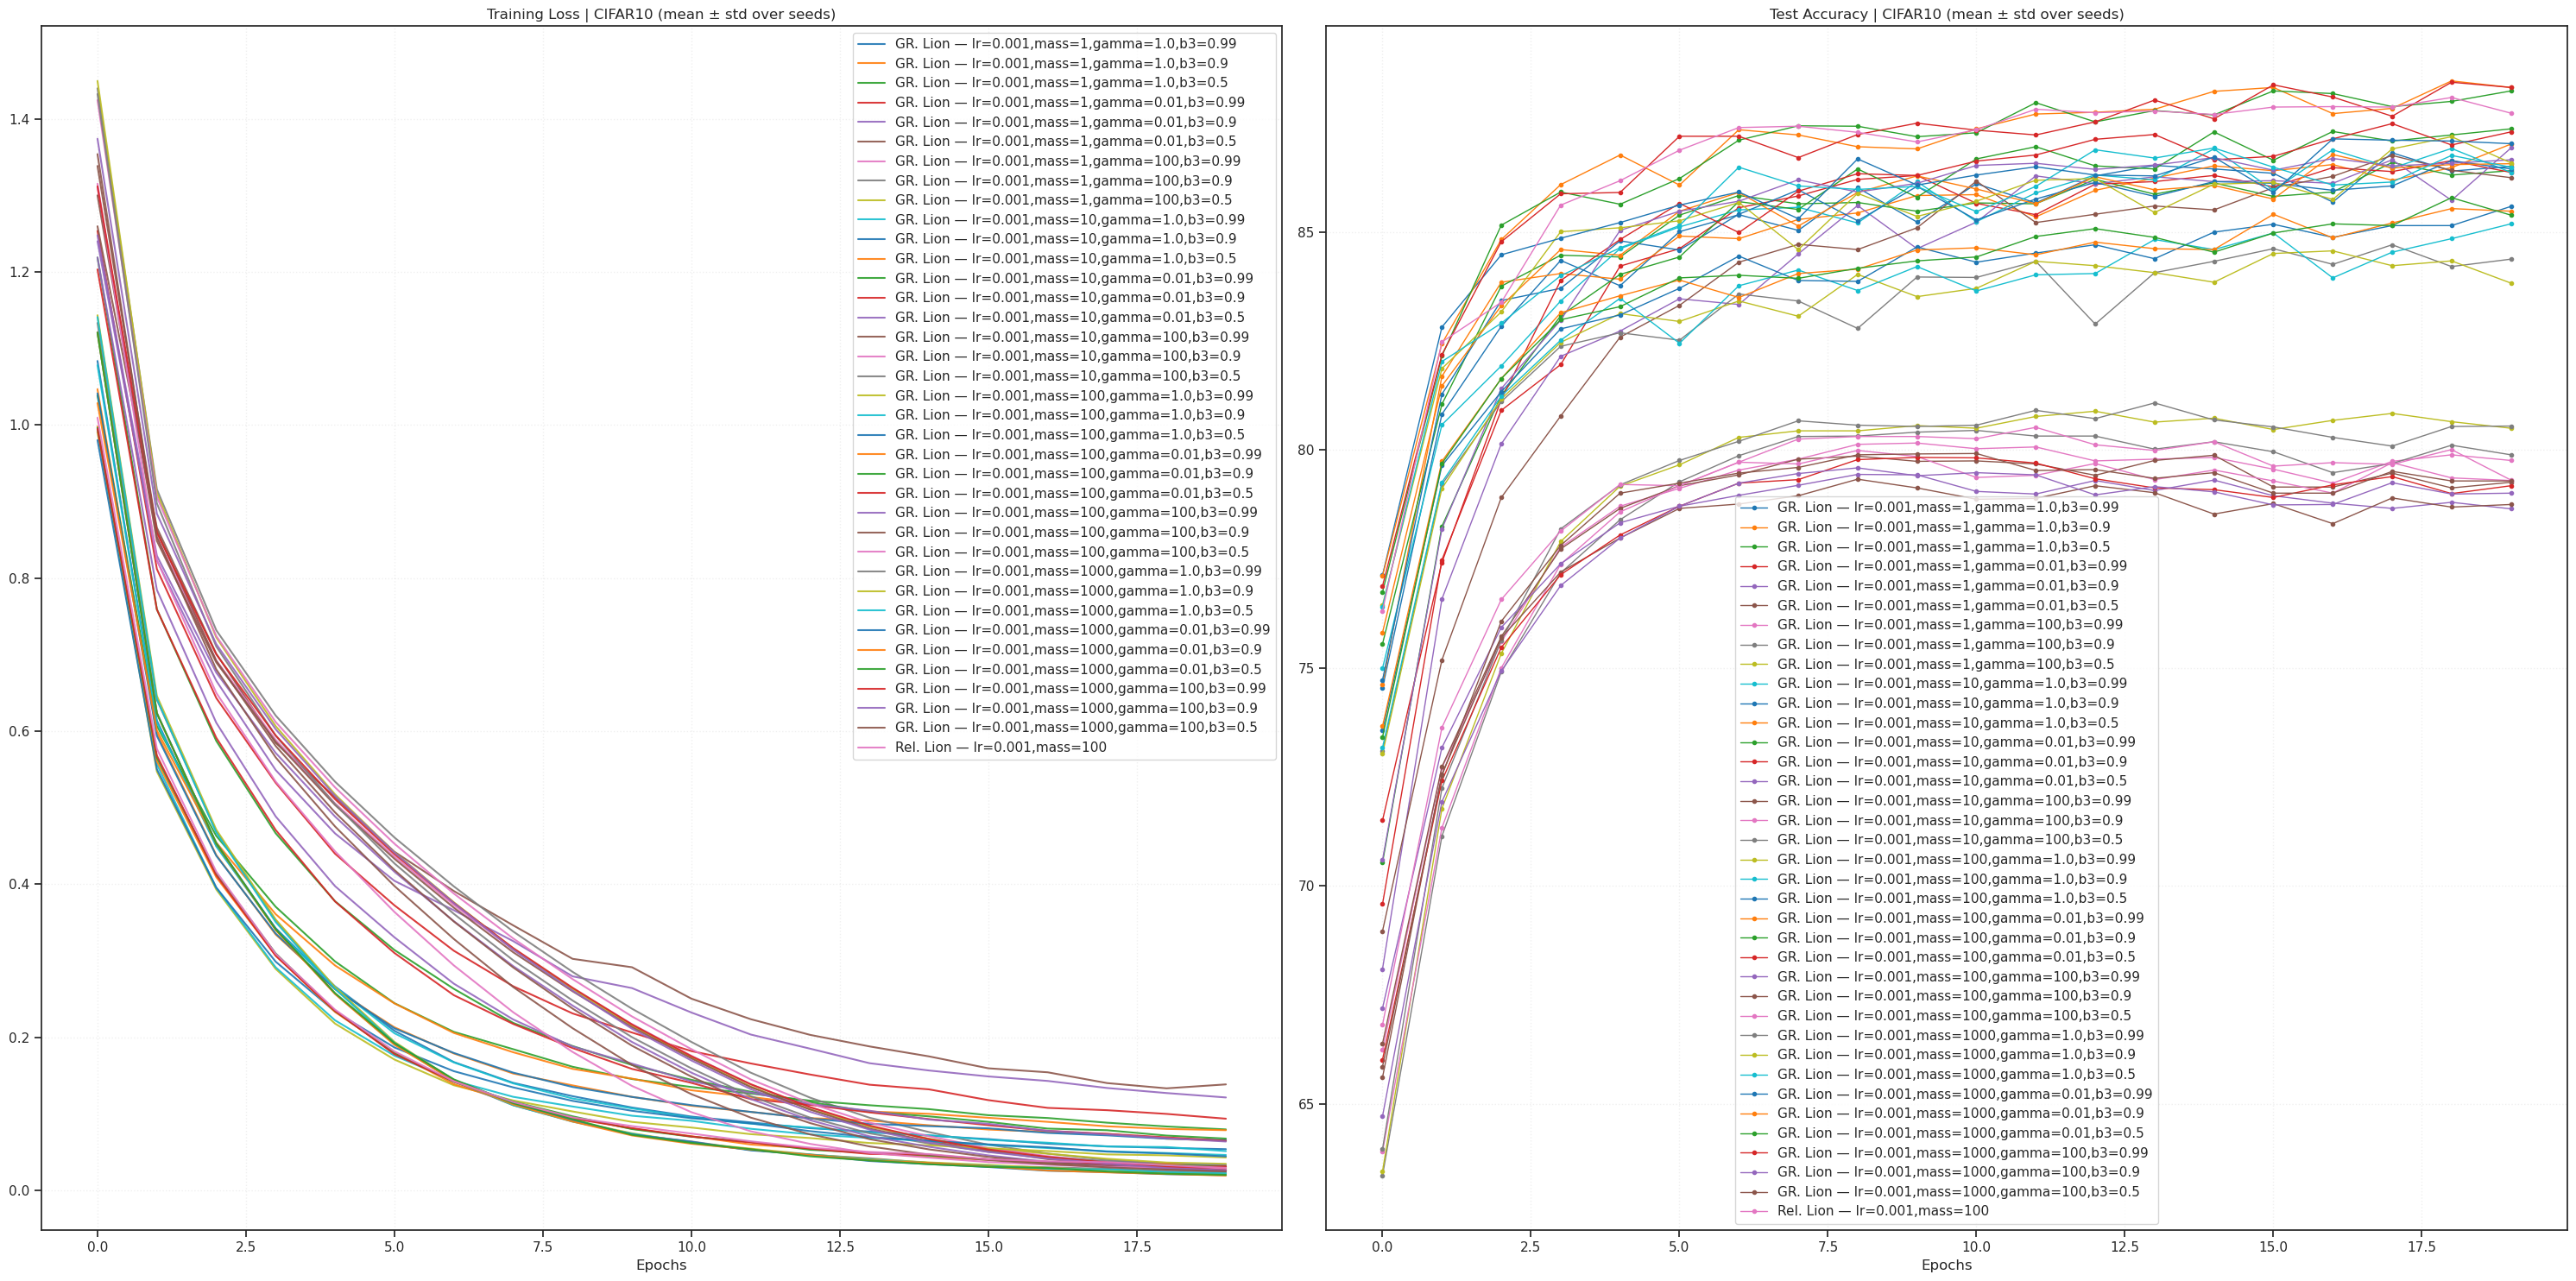

In [22]:
plot_results(results, title="CIFAR10 (mean ± std over seeds)", figsize=(30, 15))

In [19]:
avg_scores = {k: np.round(d['test_acc'].squeeze()[-5:].mean(), decimals=2) for k, d in results.items()}
avg_scores = dict(sorted(avg_scores.items(), key=lambda t: t[1]))
avg_scores

{'GR. Lion — lr=0.001,mass=100,gamma=100,b3=0.9': 78.68,
 'GR. Lion — lr=0.001,mass=100,gamma=100,b3=0.99': 78.77,
 'GR. Lion — lr=0.001,mass=1000,gamma=100,b3=0.9': 78.95,
 'GR. Lion — lr=0.001,mass=1000,gamma=100,b3=0.99': 79.14,
 'GR. Lion — lr=0.001,mass=1000,gamma=100,b3=0.5': 79.22,
 'GR. Lion — lr=0.001,mass=10,gamma=100,b3=0.99': 79.23,
 'GR. Lion — lr=0.001,mass=100,gamma=100,b3=0.5': 79.33,
 'GR. Lion — lr=0.001,mass=1,gamma=100,b3=0.99': 79.64,
 'GR. Lion — lr=0.001,mass=10,gamma=100,b3=0.9': 79.67,
 'GR. Lion — lr=0.001,mass=1,gamma=100,b3=0.9': 79.83,
 'GR. Lion — lr=0.001,mass=10,gamma=100,b3=0.5': 80.4,
 'GR. Lion — lr=0.001,mass=1,gamma=100,b3=0.5': 80.63,
 'GR. Lion — lr=0.001,mass=1000,gamma=1.0,b3=0.9': 84.3,
 'GR. Lion — lr=0.001,mass=1000,gamma=1.0,b3=0.99': 84.44,
 'GR. Lion — lr=0.001,mass=1000,gamma=1.0,b3=0.5': 84.7,
 'GR. Lion — lr=0.001,mass=1000,gamma=0.01,b3=0.99': 85.19,
 'GR. Lion — lr=0.001,mass=1000,gamma=0.01,b3=0.9': 85.3,
 'GR. Lion — lr=0.001,mass=1

## further experiments

In [4]:
cfg = TrainConfig(
    dataset='CIFAR10',
    # dataset='ImageNet32',
    batch_size=256,
    epochs=100,
    device=device,
    data_on_device=True,
    verbose=True,
    amp=False,
)

In [5]:
experiments_gr_lion = [
    Experiment(
        f"GR. Lion — lr={lr},mass={m},gamma={g},b3={b3}",
        make_opt(GeneralRelativisticLion, lr=lr, mass=m, gamma=g, beta_gravity=b3, betas=(0.8, 0.99)),
    ) for lr, m, g, b3 in itertools.product([1e-3], [100], [0.01, 0.1, 1.0], [0.99, 0.9])
]

experiments_rel_lion = [
    Experiment(
        f"Rel. Lion — lr={lr},mass={m}",
        make_opt(RelativisticLion, lr=lr, mass=m, betas=(0.8, 0.99), use_curvature=False),
    ) for lr, m in itertools.product([1e-3], [100])
]

experiments = experiments_gr_lion + experiments_rel_lion
len(experiments)

7

In [6]:
print(experiments)

[
    Experiment(
        name='GR. Lion — lr=0.001,mass=100,gamma=0.01,b3=0.99',
        opt_fn=<function make_opt.<locals>._fn at 0x7cc3cb128900>
    ),
    Experiment(
        name='GR. Lion — lr=0.001,mass=100,gamma=0.01,b3=0.9',
        opt_fn=<function make_opt.<locals>._fn at 0x7cc3cb1289a0>
    ),
    Experiment(
        name='GR. Lion — lr=0.001,mass=100,gamma=0.1,b3=0.99',
        opt_fn=<function make_opt.<locals>._fn at 0x7cc3cb128a40>
    ),
    Experiment(
        name='GR. Lion — lr=0.001,mass=100,gamma=0.1,b3=0.9',
        opt_fn=<function make_opt.<locals>._fn at 0x7cc3cb128ae0>
    ),
    Experiment(
        name='GR. Lion — lr=0.001,mass=100,gamma=1.0,b3=0.99',
        opt_fn=<function make_opt.<locals>._fn at 0x7cc3cb128b80>
    ),
    Experiment(
        name='GR. Lion — lr=0.001,mass=100,gamma=1.0,b3=0.9',
        opt_fn=<function make_opt.<locals>._fn at 0x7cc3cb128c20>
    ),
    Experiment(name='Rel. Lion — lr=0.001,mass=100', opt_fn=<function make_opt.<locals>._fn at 0x7cc3cb128860>)
]

In [7]:
%%time


results = run_experiments(experiments, cfg=cfg, seeds=[0])

--- Training (CIFAR10) ---

Model: ConvNet | seed=0
Optimizer: GeneralRelativisticLion

GeneralRelativisticLion (
Parameter Group 0
    beta_gravity: 0.99
    betas: (0.8, 0.99)
    gamma: 0.01
    lr: 0.001
    mass: 100
    weight_decay: 0.0
)

Epoch    1/100:  Train Loss 0.9980  |  Test Acc 77.11%

Epoch    5/100:  Train Loss 0.2331  |  Test Acc 86.77%

Epoch   10/100:  Train Loss 0.0805  |  Test Acc 86.91%

...

Epoch   90/100:  Train Loss 0.0048  |  Test Acc 89.30%

Epoch   95/100:  Train Loss 0.0046  |  Test Acc 88.91%

Epoch  100/100:  Train Loss 0.0049  |  Test Acc 88.71%

Finished in 517.1s

CPU times: user 1h 1s, sys: 13.9 s, total: 1h 15s
Wall time: 1h 46s


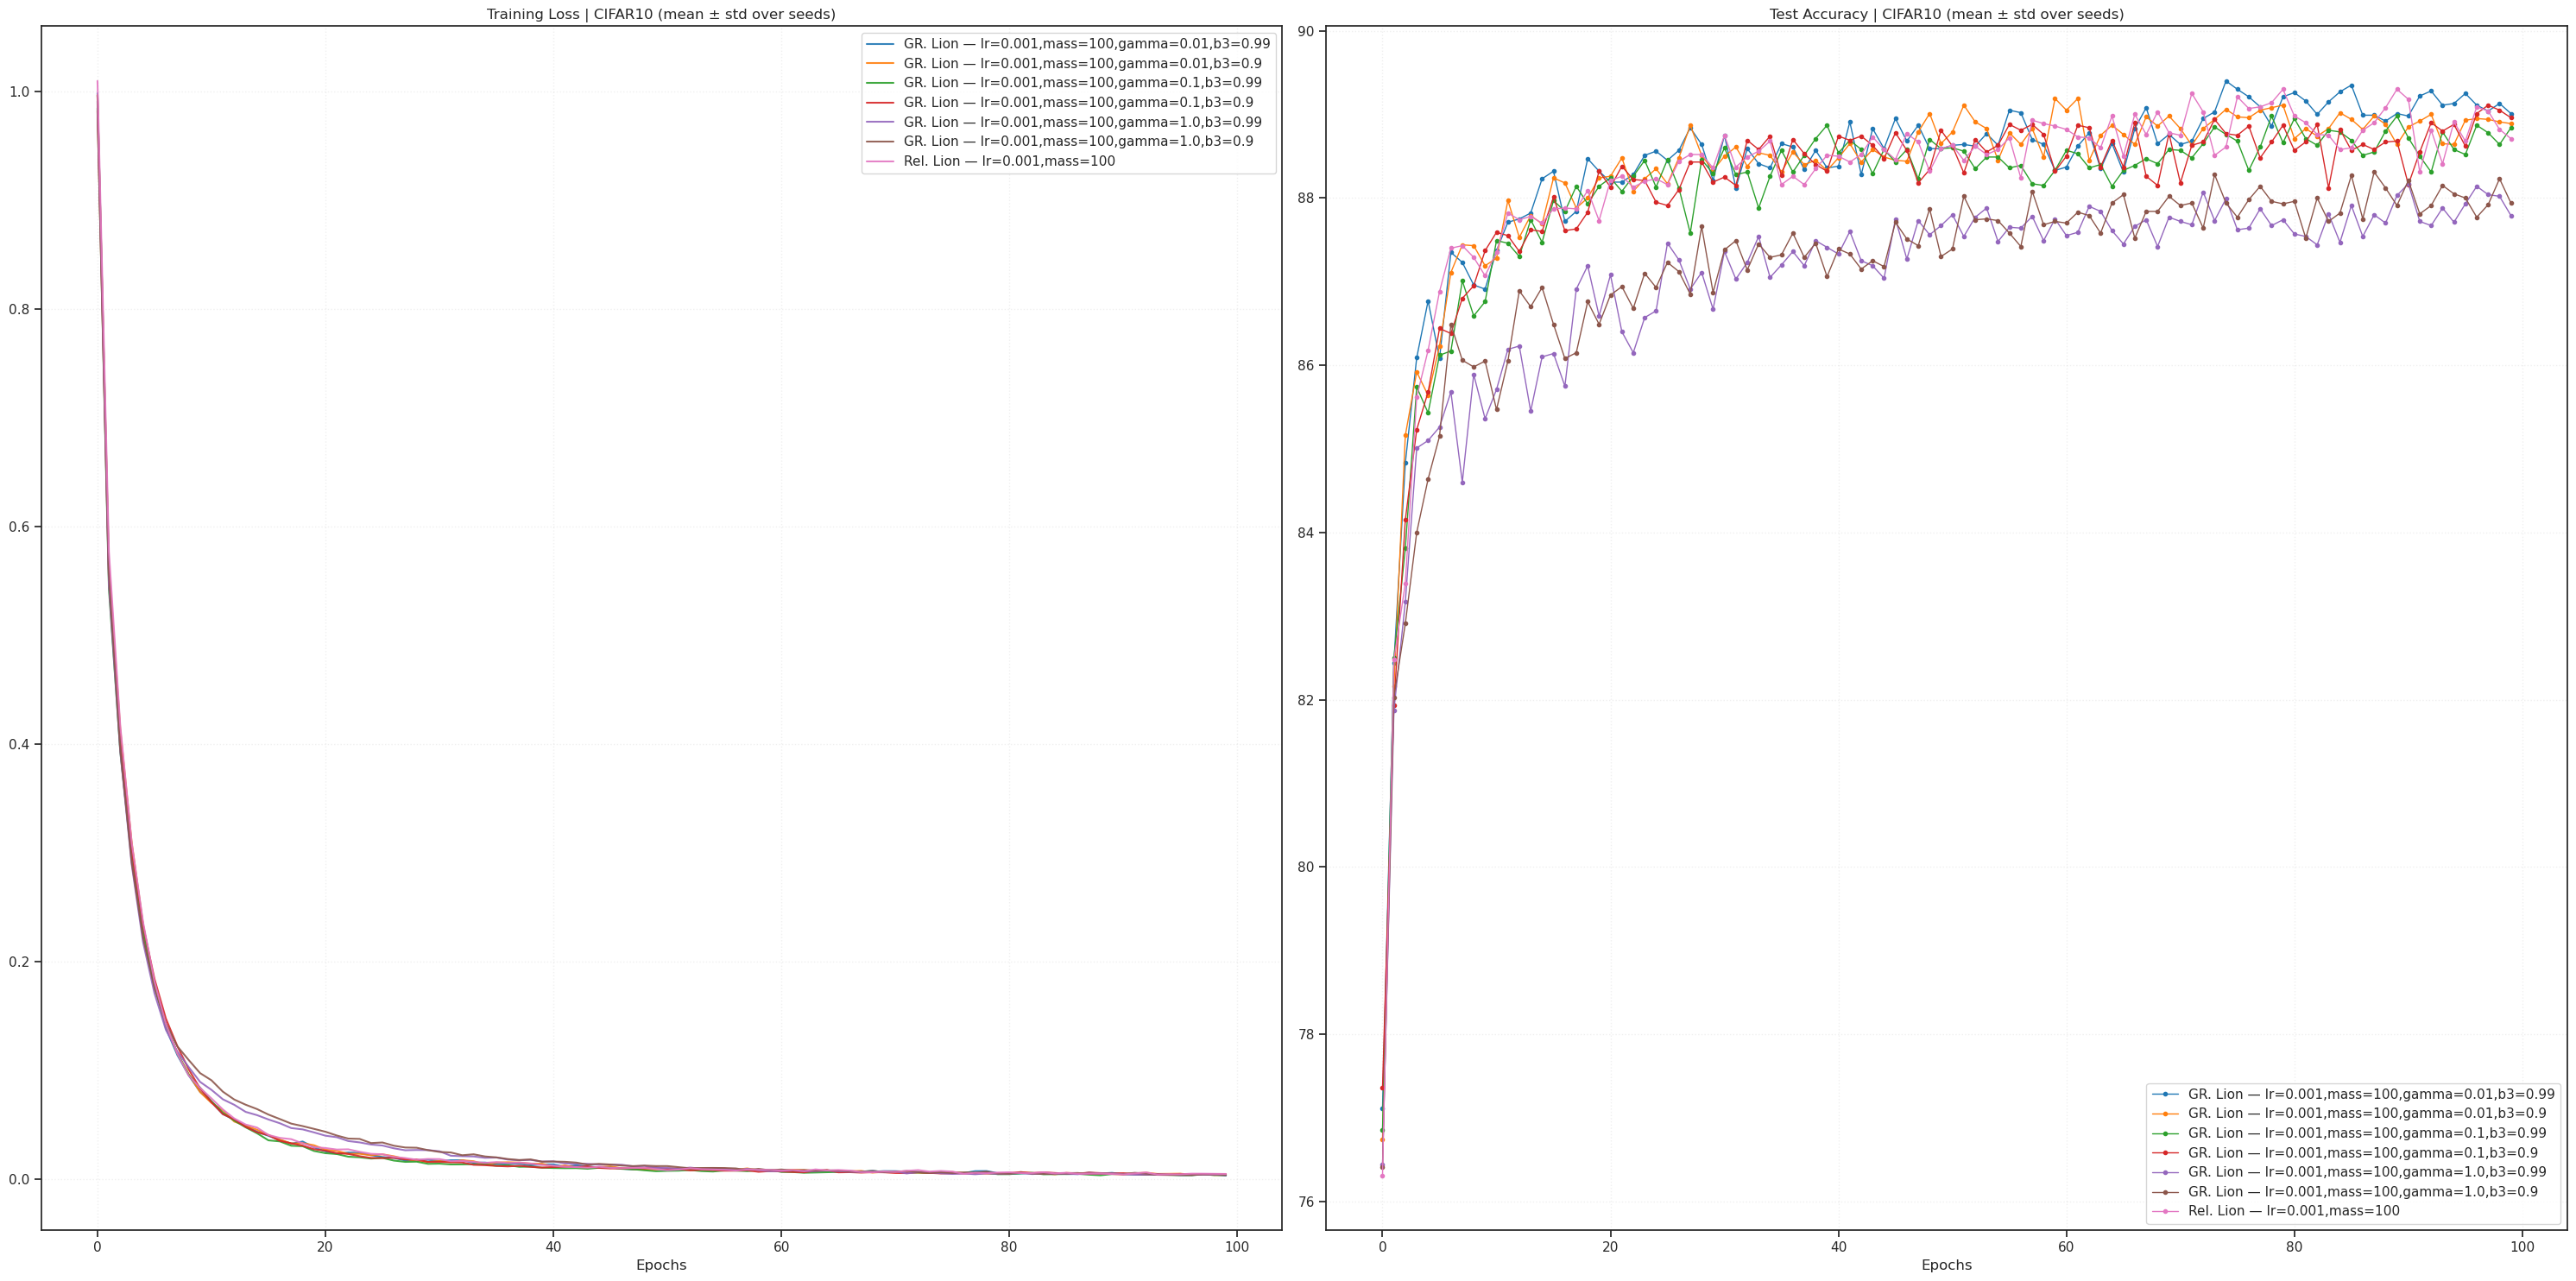

In [8]:
plot_results(results, title="CIFAR10 (mean ± std over seeds)", figsize=(30, 15))

In [9]:
avg_scores = {k: np.round(d['test_acc'].squeeze()[-5:].mean(), decimals=2) for k, d in results.items()}
avg_scores = dict(sorted(avg_scores.items(), key=lambda t: t[1]))
avg_scores

{'GR. Lion — lr=0.001,mass=100,gamma=1.0,b3=0.9': 87.97,
 'GR. Lion — lr=0.001,mass=100,gamma=1.0,b3=0.99': 87.98,
 'GR. Lion — lr=0.001,mass=100,gamma=0.1,b3=0.99': 88.73,
 'Rel. Lion — lr=0.001,mass=100': 88.87,
 'GR. Lion — lr=0.001,mass=100,gamma=0.01,b3=0.9': 88.92,
 'GR. Lion — lr=0.001,mass=100,gamma=0.1,b3=0.9': 88.95,
 'GR. Lion — lr=0.001,mass=100,gamma=0.01,b3=0.99': 89.11}

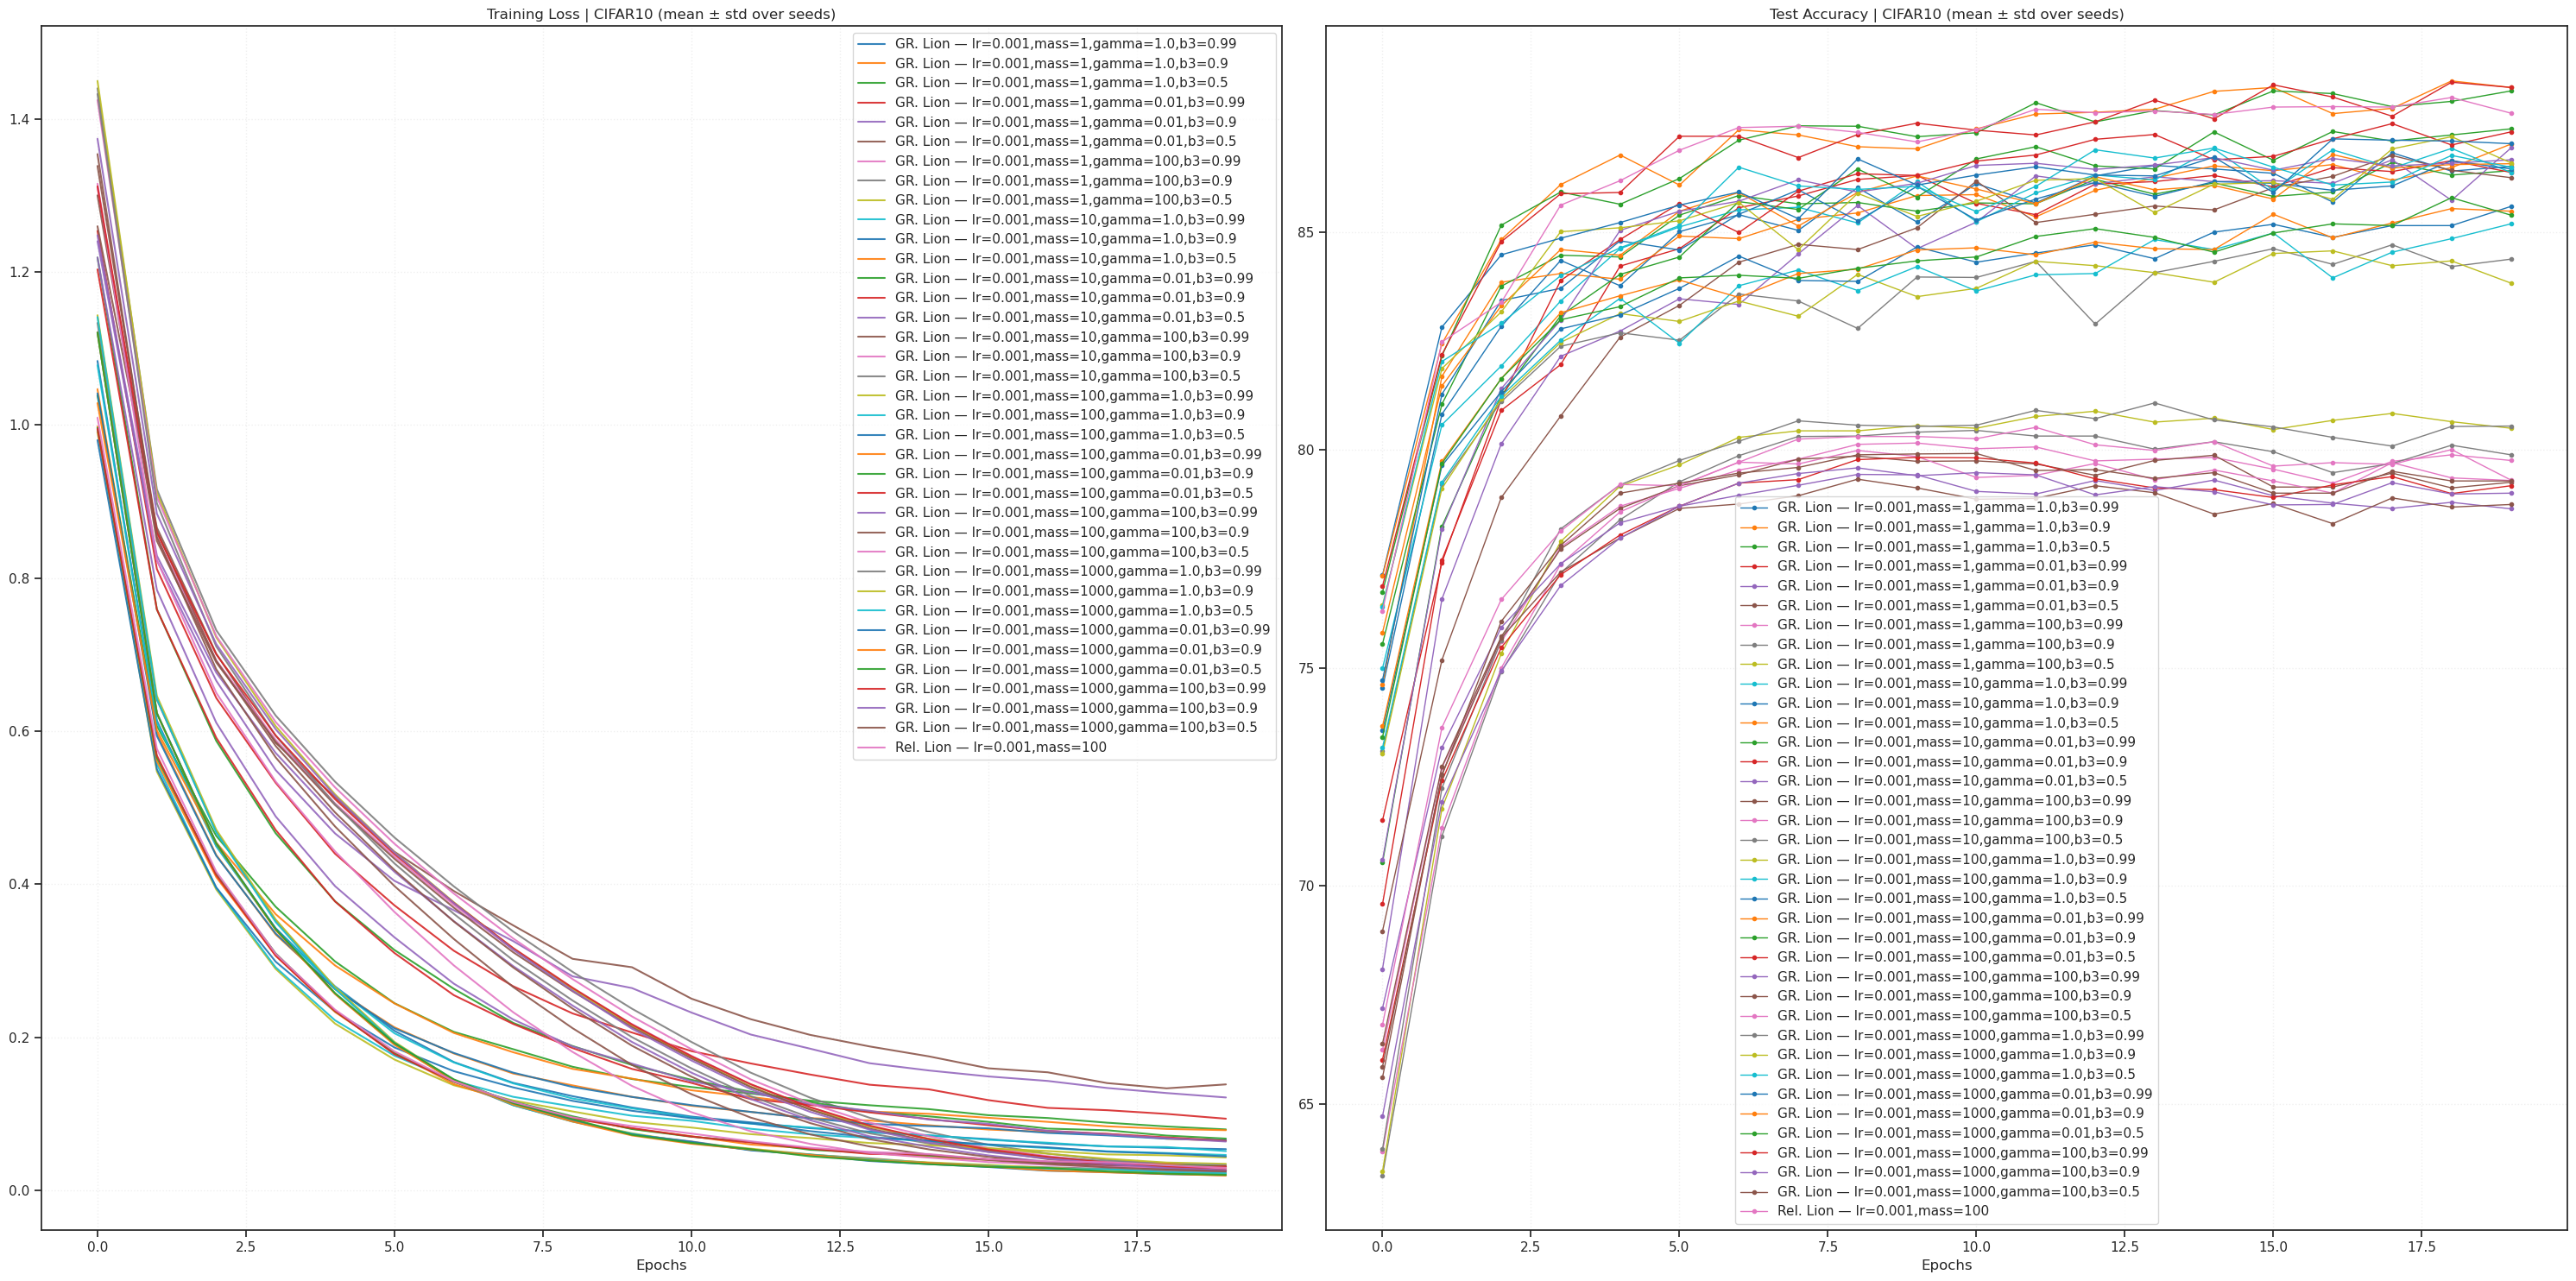

{'GR. Lion — lr=0.001,mass=100,gamma=100,b3=0.9': 78.68,
 'GR. Lion — lr=0.001,mass=100,gamma=100,b3=0.99': 78.77,
 'GR. Lion — lr=0.001,mass=1000,gamma=100,b3=0.9': 78.95,
 'GR. Lion — lr=0.001,mass=1000,gamma=100,b3=0.99': 79.14,
 'GR. Lion — lr=0.001,mass=1000,gamma=100,b3=0.5': 79.22,
 'GR. Lion — lr=0.001,mass=10,gamma=100,b3=0.99': 79.23,
 'GR. Lion — lr=0.001,mass=100,gamma=100,b3=0.5': 79.33,
 'GR. Lion — lr=0.001,mass=1,gamma=100,b3=0.99': 79.64,
 'GR. Lion — lr=0.001,mass=10,gamma=100,b3=0.9': 79.67,
 'GR. Lion — lr=0.001,mass=1,gamma=100,b3=0.9': 79.83,
 'GR. Lion — lr=0.001,mass=10,gamma=100,b3=0.5': 80.4,
 'GR. Lion — lr=0.001,mass=1,gamma=100,b3=0.5': 80.63,
 'GR. Lion — lr=0.001,mass=1000,gamma=1.0,b3=0.9': 84.3,
 'GR. Lion — lr=0.001,mass=1000,gamma=1.0,b3=0.99': 84.44,
 'GR. Lion — lr=0.001,mass=1000,gamma=1.0,b3=0.5': 84.7,
 'GR. Lion — lr=0.001,mass=1000,gamma=0.01,b3=0.99': 85.19,
 'GR. Lion — lr=0.001,mass=1000,gamma=0.01,b3=0.9': 85.3,
 'GR. Lion — lr=0.001,mass=1